# Pneumonia Detection from Chest X-Rays — Transfer Learning with ResNet-18

Pneumonia is one of the leading causes of illness and death worldwide, and timely
radiological review is central to treatment decisions. This notebook fine-tunes a
pretrained ResNet-18 to classify pediatric chest X-rays as **NORMAL** or **PNEUMONIA**.

The goal here goes beyond a single accuracy number: the notebook demonstrates a
methodologically sound workflow for a small clinical imaging dataset — correct
train/validation/test separation, a diagnosis of what goes wrong when that separation
is skipped, class-imbalance-aware evaluation, and a Grad-CAM audit of *what the model
is actually looking at* rather than just what it predicts.

**Final result** (held-out test set, n=100, observed once):
**accuracy 0.76 · F1 0.81 · sensitivity 1.00 · specificity 0.52.**
See *Conclusions & Limitations* at the end for what this number does and doesn't mean.

**Contents**
1. Exploratory Data Analysis
2. Transfer Learning Setup
3. Baseline Training *(a deliberately naive first pass, kept for contrast)*
4. Diagnosing the Baseline
5. Fixing the Methodology — validation split & early stopping
6. Final Evaluation
7. Explainability with Grad-CAM
8. Model Persistence
9. Testing a Hypothesis — Framing-Robust Augmentation *(an honest negative result)*
10. Deeper Fine-Tuning — Unfreezing `layer4` *(overfits; test-set result ties step 6)*
11. Completing the 2×2 — Augmentation × `layer4` *(best numbers, but an unstable run)*

Conclusions & Limitations

## Original Assignment Brief

Pneumonia is one of the leading respiratory illnesses worldwide, and its timely and accurate diagnosis is essential for effective treatment. Manually reviewing chest X-rays is a critical step in this process, and AI can provide valuable support by helping to expedite the assessment. In your role as a consultant data scientist, you will test the ability of a deep learning model to distinguish pneumonia cases from normal images of lungs in chest X-rays.

By fine-tuning a pre-trained convolutional neural network, specifically the ResNet-18 model, your task is to classify X-ray images into two categories: normal lungs and those affected by pneumonia. You can leverage its already trained weights and get an accurate classifier trained faster and with fewer resources.

### The Data

<img src="x-rays_sample.png" align="center"/>
&nbsp

You have a dataset of chest X-rays that have been preprocessed for use with a ResNet-18 model. You can see a sample of 5 images from each category above. Upon unzipping the `chestxrays.zip` file (code provided below), you will find your dataset inside the `data/chestxrays` folder divided into `test` and `train` folders.

There are 150 training images and 50 testing images for each category, NORMAL and PNEUMONIA (300 and 100 in total). For your convenience, this data has already been loaded into a `train_loader` and a `test_loader` using the `DataLoader` class from the PyTorch library.

In [1]:
%matplotlib inline

# Import required libraries
# -------------------------
# Data loading
import random
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Train model
import torch
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# Evaluate model
from torchmetrics import Accuracy, F1Score

# Set random seeds for reproducibility
torch.manual_seed(101010)
np.random.seed(101010)
random.seed(101010)

In [2]:
import os
import zipfile

# Unzip the data folder
if not os.path.exists('data/chestxrays'):
    with zipfile.ZipFile('data/chestxrays.zip', 'r') as zip_ref:
        zip_ref.extractall('data')

In [3]:
# Define the transformations to apply to the images for use with ResNet-18
transform_mean = [0.485, 0.456, 0.406]
transform_std =[0.229, 0.224, 0.225]
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=transform_mean, std=transform_std)])

# Apply the image transforms
train_dataset = ImageFolder('data/chestxrays/train', transform=transform)
test_dataset = ImageFolder('data/chestxrays/test', transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset) // 2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

## 1. Exploratory Data Analysis

Before touching the model, we look at the data. In medical imaging, models most often
fail because of the data — artifacts, class imbalance, leakage between splits — not
because of the architecture.

We check three things:
1. **Label mapping** — `ImageFolder` assigns classes alphabetically, so we expect
   `NORMAL=0`, `PNEUMONIA=1`. This needs to be *verified*, not assumed — it determines
   how the sigmoid output is interpreted at evaluation time.
2. **Class balance** — computed from the data, not taken on faith from the task description.
3. **Raw images** — do we see the expected disease signature (whitish consolidation in
   the lung fields)? And do the two classes differ in ways *unrelated* to disease (film
   markers, contrast, framing)? This is the risk of **shortcut learning** — a model can
   learn to recognize the imaging equipment or acquisition protocol instead of the
   pathology itself.

In [4]:
# 1a. Label mapping and class balance
# ------------------------------------
from collections import Counter

# ImageFolder assigns class indices alphabetically
print("Class mapping:", {name: idx for idx, name in enumerate(train_dataset.classes)})

# .targets holds every label in the dataset — we count rather than trust the description
train_counts = Counter(train_dataset.targets)
test_counts = Counter(test_dataset.targets)

for name, idx in train_dataset.class_to_idx.items():
    print(f"{name:10s}  train: {train_counts[idx]:3d}   test: {test_counts[idx]:3d}")

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
NORMAL      train: 150   test:  50
PNEUMONIA   train: 150   test:  50


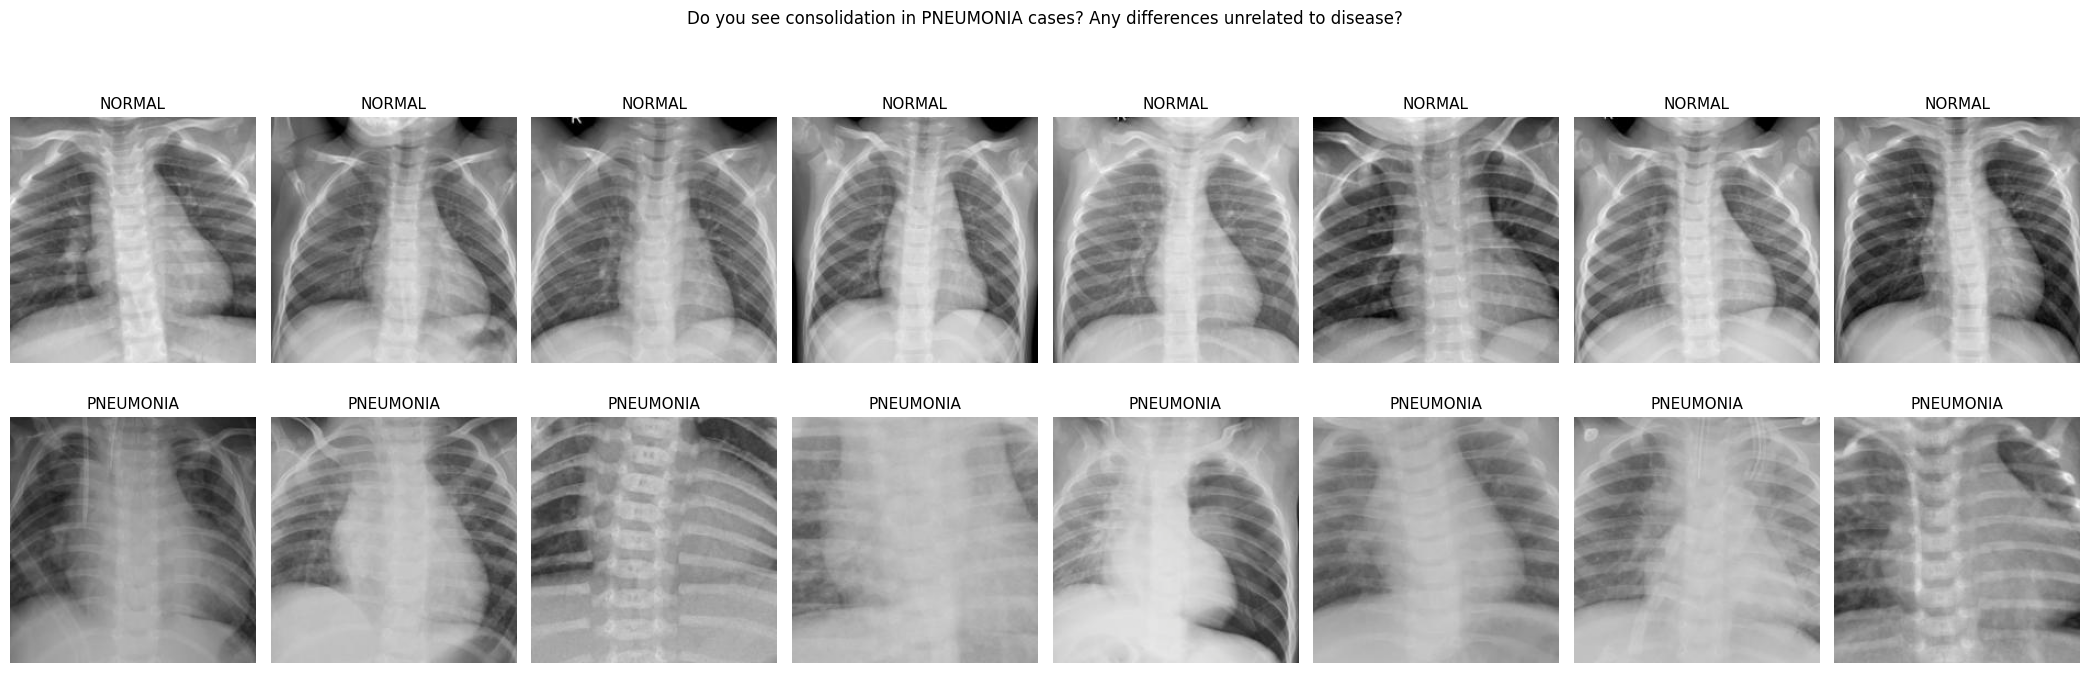

In [5]:
# 1b. Sampling raw images (top row: NORMAL, bottom row: PNEUMONIA)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

# Tensors are normalized for ImageNet — to see the "real" X-ray we invert it:
# x_norm = (x - mean) / std  =>  x = x_norm * std + mean
mean = torch.tensor(transform_mean).view(3, 1, 1)   # (3,1,1) so it broadcasts across channels
std = torch.tensor(transform_std).view(3, 1, 1)

def denormalize(img):
    return (img * std + mean).clamp(0, 1)

normal_idx = [i for i, t in enumerate(train_dataset.targets) if t == 0][:8]
pneumonia_idx = [i for i, t in enumerate(train_dataset.targets) if t == 1][:8]

fig, axes = plt.subplots(2, 8, figsize=(21, 7))
for ax, idx in zip(axes.flat, normal_idx + pneumonia_idx):
    img, label = train_dataset[idx]                 # (3, 224, 224) — channels first
    img = denormalize(img).permute(1, 2, 0)         # imshow wants (224, 224, 3) — channels last
    ax.imshow(img)
    ax.set_title(train_dataset.classes[label], fontsize=11)
    ax.axis("off")

fig.suptitle("Do you see consolidation in PNEUMONIA cases? Any differences unrelated to disease?", y=1.02)
plt.tight_layout()
plt.show()

## 2. Transfer Learning Setup

ResNet-18 was pretrained on ImageNet: 1.2M natural images, 1000 classes (dogs, cars,
…). Why does that help with X-rays? Because **early CNN layers learn general-purpose
features** — edges, textures, brightness gradients — and only the later layers assemble
those into task-specific concepts. Edges and textures are just as useful on a chest
X-ray as on a photo of a dog. (Empirically, ImageNet features transfer to medical
imaging surprisingly well despite the domain gap — this is a standard starting point in
radiology ML.)

Model surgery:
1. **Freeze the entire backbone** (`requires_grad = False`) — leaves ~11M parameters
   untouched. With only 300 training images, fine-tuning the full network would overfit
   almost immediately: the model would memorize the training set instead of generalizing.
2. **Replace the head**: the original `fc` is `Linear(512 → 1000)` (ImageNet classes).
   We swap in a fresh, trainable `Linear(512 → 1)`.

Why **one output, not two**? For binary classification a single logit is enough:
`sigmoid(logit)` gives the probability of class `1` — PNEUMONIA, per the mapping
confirmed in step 1. Two outputs plus softmax would be mathematically equivalent, but
the provided evaluation code later in this notebook expects the sigmoid formulation, so
the loss function in step 3 is matched to it.

In [6]:
# 2a. Load the pretrained ResNet-18
# -------------------------------------
# Pretrained weights download to TORCH_HOME — pointed at ./models (mounted from the
# host) so they survive container restarts instead of re-downloading every time
os.environ["TORCH_HOME"] = "models"

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

total_params = sum(p.numel() for p in resnet18.parameters())
print(f"Total parameters: {total_params:,}")
print("Original head:", resnet18.fc)  # Linear(512 -> 1000 ImageNet classes)

Total parameters: 11,689,512
Original head: Linear(in_features=512, out_features=1000, bias=True)


In [7]:
# 2b. Freeze the backbone, replace the head
# --------------------------------------------
for param in resnet18.parameters():
    param.requires_grad = False

# The new layer has requires_grad=True by default — it's the only thing we'll train.
# in_features is read off the model rather than hardcoded as 512
resnet18.fc = nn.Linear(resnet18.fc.in_features, 1)

trainable_names = [name for name, p in resnet18.named_parameters() if p.requires_grad]
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"Trainable tensors: {trainable_names}")
print(f"Trainable parameters: {trainable_params:,} of {total_params:,} "
      f"({100 * trainable_params / total_params:.3f}%)")

# Shape sanity check: a batch of 2 images should produce 2 logits
with torch.no_grad():
    dummy_out = resnet18(torch.randn(2, 3, 224, 224))
print("Output shape for a batch of 2:", tuple(dummy_out.shape))

Trainable tensors: ['fc.weight', 'fc.bias']
Trainable parameters: 513 of 11,689,512 (0.004%)


Output shape for a batch of 2: (2, 1)


## 3. Baseline Training (a deliberately naive first pass)

This first attempt is kept in the notebook on purpose — it illustrates two very common
training pitfalls, and the *diagnosis* in the next section is exactly how you catch
them in practice.

Components:
- **Loss:** `BCEWithLogitsLoss` — takes raw logits and applies a numerically stable
  sigmoid internally. (Sigmoid saturates: a logit of -40 rounds to `0.0` in float32, so
  `log(0) = -inf` and training explodes with NaNs unless the sigmoid and the log are
  fused into one stable expression. Rule of thumb: *apply sigmoid/softmax only for
  interpretation, never before the loss.*)
- **Optimizer:** Adam, restricted to the head's parameters (`resnet18.fc.parameters()`)
  — the frozen backbone has no gradients anyway, but the explicit restriction is a
  readable statement of intent and a safety net.
- **Labels:** the loader yields `int64` of shape `(batch,)`; the loss expects `float32`
  of shape `(batch, 1)`, matching the model's output → `labels.float().unsqueeze(1)`.

The anatomy of one training step (worth knowing by heart):
1. `optimizer.zero_grad()` — clear gradients from the previous step (PyTorch
   *accumulates* them by default),
2. forward pass — compute predictions and loss,
3. `loss.backward()` — compute gradients via autograd,
4. `optimizer.step()` — update the weights.

**What's naive here:** `train_loader` uses `batch_size = len(train_dataset) // 2`, i.e.
two giant batches per epoch — only **2 gradient updates per epoch**. Combined with a
relatively high learning rate (0.01), this starves the 513-parameter head of the many
small corrective steps it needs. There is also no validation set yet, so there is no
honest way to tell *when* to stop.

In [8]:
# 3. Training the classification head (baseline)
# --------------------------------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.01)

num_epochs = 15

for epoch in range(num_epochs):
    resnet18.train()
    epoch_loss = 0.0
    epoch_correct = 0

    for inputs, labels in train_loader:
        labels = labels.float().unsqueeze(1)   # int64 (batch,) -> float32 (batch, 1)

        optimizer.zero_grad()                  # 1. clear stale gradients
        outputs = resnet18(inputs)             # 2. forward: logits (batch, 1)
        loss = criterion(outputs, labels)      #    loss on raw logits
        loss.backward()                        # 3. compute gradients
        optimizer.step()                       # 4. update the head's weights

        # Bookkeeping (outside the computation graph, hence .item()/.detach())
        epoch_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs.detach()) > 0.5).float()
        epoch_correct += (preds == labels).sum().item()

    n = len(train_dataset)
    print(f"Epoch {epoch + 1}/{num_epochs}  "
          f"loss: {epoch_loss / n:.4f}  "
          f"train acc: {epoch_correct / n:.3f}")

Epoch 1/15  loss: 1.0363  train acc: 0.537


Epoch 2/15  loss: 0.7455  train acc: 0.563


Epoch 3/15  loss: 0.6838  train acc: 0.617


Epoch 4/15  loss: 0.4519  train acc: 0.777


Epoch 5/15  loss: 0.4842  train acc: 0.753


...

Epoch 11/15  loss: 0.2468  train acc: 0.903


Epoch 12/15  loss: 0.2166  train acc: 0.913


Epoch 13/15  loss: 0.2226  train acc: 0.910


Epoch 14/15  loss: 0.2172  train acc: 0.903


Epoch 15/15  loss: 0.2025  train acc: 0.910


### Evaluating the baseline model (provided evaluation code)

Run below to score the current model on the test set. The code in this cell is
provided as-is by the assignment.

In [9]:
#-------------------
# Evaluate the model
#-------------------

# Set model to evaluation mode
model = resnet18
model.eval()

# Initialize metrics for accuracy and F1 score
accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

# Create lists store all predictions and labels
all_preds = []
all_labels = []

# Disable gradient calculation for evaluation
with torch.no_grad():
  for inputs, labels in test_loader:
    # Forward pass
    outputs = model(inputs)
    preds = torch.sigmoid(outputs).round()  # Round to 0 or 1

    # Extend the lists with predictions and labels
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.unsqueeze(1).tolist())

    # Convert lists back to tensors
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)

    # Calculate accuracy and F1 score
    test_acc = accuracy_metric(all_preds, all_labels).item()
    test_f1 = f1_metric(all_preds, all_labels).item()

## 4. Diagnosing the Baseline

Accuracy and F1 are aggregate numbers — in medicine we need to know precisely **what
kind of mistakes** the model makes and **which ones matter**. We break the result down
into a confusion matrix:

|                       | pred: NORMAL | pred: PNEUMONIA |
|-----------------------|--------------|------------------|
| **actual: NORMAL**    | TN           | FP (false alarm) |
| **actual: PNEUMONIA** | **FN (missed case!)** | TP |

From it we derive the pair of metrics diagnostics actually cares about:
- **Sensitivity** (recall) = TP / (TP + FN) — *what fraction of sick patients did we
  catch*. Low sensitivity means missed pneumonia cases — the most dangerous failure
  mode in a screening tool.
- **Specificity** = TN / (TN + FP) — *what fraction of healthy patients did we
  correctly reassure*. Low specificity means false alarms and unnecessary follow-up.

Why can F1 be much lower than accuracy? F1 only looks at the positive class
(PNEUMONIA): if the model "plays it safe" and leans toward predicting NORMAL, accuracy
can still look decent (healthy patients are classified fine), while sensitivity — and
F1 with it — collapses.

In [10]:
# 4. Confusion-matrix helper, applied to the baseline
# -----------------------------------------------------
def confusion_report(preds, labels, acc, f1):
    """Prints a confusion matrix and derived clinical metrics for binary predictions."""
    tp = ((preds == 1) & (labels == 1)).sum().item()
    tn = ((preds == 0) & (labels == 0)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()

    sensitivity = tp / (tp + fn) if tp + fn else float("nan")
    specificity = tn / (tn + fp) if tn + fp else float("nan")
    precision = tp / (tp + fp) if tp + fp else float("nan")

    print(f"Accuracy: {acc:.3f}   F1: {f1:.3f}\n")
    print("                    pred NORMAL   pred PNEUMONIA")
    print(f"actual NORMAL:         TN={tn:3d}          FP={fp:3d}")
    print(f"actual PNEUMONIA:      FN={fn:3d}          TP={tp:3d}\n")
    print(f"Sensitivity (recall): {sensitivity:.3f}  <- fraction of sick patients detected")
    print(f"Specificity:          {specificity:.3f}  <- fraction of healthy patients correctly cleared")
    print(f"Precision:            {precision:.3f}  <- fraction of alarms that were correct")
    print(f"\nMissed cases (FN): {fn} of {tp + fn} pneumonia patients")
    return dict(tp=tp, tn=tn, fp=fp, fn=fn,
                sensitivity=sensitivity, specificity=specificity, precision=precision)

baseline_report = confusion_report(all_preds, all_labels, test_acc, test_f1)

Accuracy: 0.610   F1: 0.719

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 11          FP= 39
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.220  <- fraction of healthy patients correctly cleared
Precision:            0.562  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients


## 5. Fixing the Methodology

The baseline above is unstable — small hyperparameter changes during development swung
sensitivity anywhere between 0.38 and 1.00, with specificity moving in the opposite
direction. Two causes: (a) only 2 gradient steps per epoch at batch size 150, (b) a
learning rate (0.01) that lets the 513-parameter head overshoot instead of settling. A
third, easy-to-miss problem is methodological: **deciding how many epochs to train by
looking at test-set performance is a form of data leakage** — the test set stops
measuring generalization the moment it starts influencing decisions. It should be
observed **once, at the very end**.

We fix all three:
1. **Validation split** — carve 20% off the training set, **stratified** (equal
   proportion per class) so the 60 held-out images mirror the 50/50 class balance of the
   full set. Model-selection decisions (epochs, learning rate, batch size, decision
   threshold) are made against this split; the test set stays untouched until the final
   evaluation.
2. **Smaller batches (8)** — 240⁄8 = 30 gradient steps per epoch instead of 2.
3. **Lower learning rate (0.001)** — smoother convergence, less oscillation.
4. **Checkpointing the best epoch** — track validation loss after every epoch and keep
   the weights from its minimum (a simple form of early stopping), rather than whatever
   the training loop happens to end on.

What to watch for in the printed log: training and validation loss should fall
*together*. When training loss keeps dropping while validation loss turns back up,
that's the textbook signature of **overfitting** — further epochs are memorizing, not
generalizing.

In [11]:
# 5a. Stratified train -> train/val split, new data loaders
# -------------------------------------------------------------
from torch.utils.data import Subset

val_fraction = 0.2
rng = np.random.default_rng(101010)   # a dedicated generator — doesn't touch the global seeds

train_idx, val_idx = [], []
for cls in (0, 1):
    cls_idx = [i for i, t in enumerate(train_dataset.targets) if t == cls]
    cls_idx = rng.permutation(cls_idx)                # shuffle within the class
    n_val = int(len(cls_idx) * val_fraction)
    val_idx.extend(cls_idx[:n_val])                   # 30 per class go to validation
    train_idx.extend(cls_idx[n_val:])                 # the rest stay in training

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(train_dataset, val_idx)

# Smaller batches -> more gradient steps per epoch
train_loader_s = DataLoader(train_subset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64)

print(f"train: {len(train_subset)}  val: {len(val_subset)}  "
      f"(gradient steps/epoch: {len(train_loader_s)})")

train: 240  val: 60  (gradient steps/epoch: 30)


In [12]:
# 5b. Training from scratch with validation monitoring and best-epoch checkpointing
# --------------------------------------------------------------------------------
import copy

def make_model():
    '''A fresh frozen ResNet-18 with a new head — every experiment starts from a clean slate.'''
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, 1)
    return m

def evaluate_loss(m, loader):
    '''Mean loss and accuracy on a given loader (no gradient tracking).'''
    m.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            labels = labels.float().unsqueeze(1)
            outputs = m(inputs)
            total_loss += criterion(outputs, labels).item() * inputs.size(0)
            correct += ((torch.sigmoid(outputs) > 0.5).float() == labels).sum().item()
            n += inputs.size(0)
    return total_loss / n, correct / n

resnet18 = make_model()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001)

num_epochs = 25
best_val_loss = float("inf")
best_state = None
best_epoch = -1

for epoch in range(num_epochs):
    resnet18.train()
    for inputs, labels in train_loader_s:
        labels = labels.float().unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(resnet18(inputs), labels)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate_loss(resnet18, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18, val_loader)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(resnet18.state_dict())
        best_epoch = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18.load_state_dict(best_state)
torch.save(best_state, "models/resnet18_pneumonia_head.pt")
print(f"\nRestored weights from epoch {best_epoch} (val loss {best_val_loss:.4f}); "
      f"saved to models/resnet18_pneumonia_head.pt")

Epoch  1/25  train: 0.7799 (acc 0.500)  val: 0.7982 (acc 0.517)  <- best so far


Epoch  2/25  train: 0.4643 (acc 0.796)  val: 0.5059 (acc 0.733)  <- best so far


Epoch  3/25  train: 0.3300 (acc 0.883)  val: 0.4115 (acc 0.800)  <- best so far


Epoch  4/25  train: 0.3121 (acc 0.896)  val: 0.3935 (acc 0.883)  <- best so far


Epoch  5/25  train: 0.2713 (acc 0.917)  val: 0.3647 (acc 0.917)  <- best so far


...

Epoch 22/25  train: 0.1413 (acc 0.950)  val: 0.3123 (acc 0.867)  <- best so far


Epoch 23/25  train: 0.1398 (acc 0.958)  val: 0.3175 (acc 0.867)


Epoch 24/25  train: 0.1507 (acc 0.954)  val: 0.3391 (acc 0.900)


Epoch 25/25  train: 0.1478 (acc 0.958)  val: 0.3209 (acc 0.867)



Restored weights from epoch 22 (val loss 0.3123); saved to models/resnet18_pneumonia_head.pt


## 6. Final Evaluation (test set, observed once)

This is the only other point in the notebook where the test set is used. The same
provided evaluation cell from step 3 is re-run — now against the model selected by
validation in step 5 — followed by the same confusion-matrix breakdown. These are the
numbers actually reported.

In [13]:
#-------------------
# Evaluate the model
#-------------------

# Set model to evaluation mode
model = resnet18
model.eval()

# Initialize metrics for accuracy and F1 score
accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

# Create lists store all predictions and labels
all_preds = []
all_labels = []

# Disable gradient calculation for evaluation
with torch.no_grad():
  for inputs, labels in test_loader:
    # Forward pass
    outputs = model(inputs)
    preds = torch.sigmoid(outputs).round()  # Round to 0 or 1

    # Extend the lists with predictions and labels
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.unsqueeze(1).tolist())

    # Convert lists back to tensors
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)

    # Calculate accuracy and F1 score
    test_acc = accuracy_metric(all_preds, all_labels).item()
    test_f1 = f1_metric(all_preds, all_labels).item()

In [14]:
# Final confusion matrix — the validated model, test set observed once
final_report = confusion_report(all_preds, all_labels, test_acc, test_f1)

Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients


## 7. Explainability with Grad-CAM

"The model says PNEUMONIA" isn't enough in a clinical context — the natural follow-up
is *based on what evidence?* Grad-CAM (Gradient-weighted Class Activation Mapping)
answers with a heatmap overlaid on the image: which regions pushed the prediction most
strongly toward a given class.

The intuition:
1. Take the activations of the **last convolutional block** (`layer4` → 512 feature
   maps, 7×7) — the last point in the network where the representation still has
   spatial structure.
2. Compute the **gradient of the logit with respect to those activations**: "if this
   feature map were stronger, how much would the PNEUMONIA score increase?" Averaging
   the gradient spatially gives one importance weight per feature map.
3. Sum the maps weighted by those importances, clip negative values with ReLU (keep
   only what *supports* the class), and upsample from 7×7 to 224×224.

Two implementation details worth remembering:
- The backbone is frozen (`requires_grad=False`), so autograd normally **won't**
  compute gradients with respect to `layer4`'s activations — nothing downstream needs
  them. The fix: enable gradients on the *input image* itself, which pulls every
  intermediate activation back into the backward graph.
- Activations and gradients are captured with **hooks**
  (`register_forward_hook` / `register_full_backward_hook`) — a general-purpose
  technique for inspecting the internals of any `nn.Module`.

How to read the maps: heat over the lung fields is reassuring; heat concentrated on
image borders, film markers, shoulders, or the diaphragm raises the shortcut-learning
concern from step 1. And a note of interpretive humility: the underlying resolution is
a mere 7×7, and Grad-CAM is **circumstantial evidence, not proof** — it shows what
correlates with the decision, not what caused it.

In [15]:
# 7a. Grad-CAM implementation (from scratch, using hooks — no external libraries)
# ---------------------------------------------------------------------------------
import torch.nn.functional as F

_saved = {}

def _forward_hook(module, args, output):
    _saved["act"] = output                    # layer4 activations: (1, 512, 7, 7)

def _backward_hook(module, grad_input, grad_output):
    _saved["grad"] = grad_output[0]           # gradient of the logit w.r.t. activations

def grad_cam(model, img):
    '''Returns (224x224 heatmap in [0,1], PNEUMONIA probability) for a single image.'''
    model.eval()
    h_fwd = model.layer4.register_forward_hook(_forward_hook)
    h_bwd = model.layer4.register_full_backward_hook(_backward_hook)
    try:
        x = img.unsqueeze(0).clone().requires_grad_(True)  # gradient on the input revives backward
        logit = model(x)                                   # (1, 1)
        model.zero_grad()
        logit.backward()

        act = _saved["act"].squeeze(0)                     # (512, 7, 7)
        grad = _saved["grad"].squeeze(0)                   # (512, 7, 7)
        weights = grad.mean(dim=(1, 2))                    # importance of each map: (512,)
        cam = torch.relu((weights[:, None, None] * act).sum(dim=0))  # (7, 7)

        cam = F.interpolate(cam[None, None], size=(224, 224),
                            mode="bilinear", align_corners=False).squeeze()
        if cam.max() > 0:
            cam = cam / cam.max()                          # scale to [0, 1] for plotting
        return cam.detach(), torch.sigmoid(logit).item()
    finally:
        h_fwd.remove()                                     # always clean up hooks —
        h_bwd.remove()                                     # otherwise they stay attached forever

print("grad_cam ready")

grad_cam ready


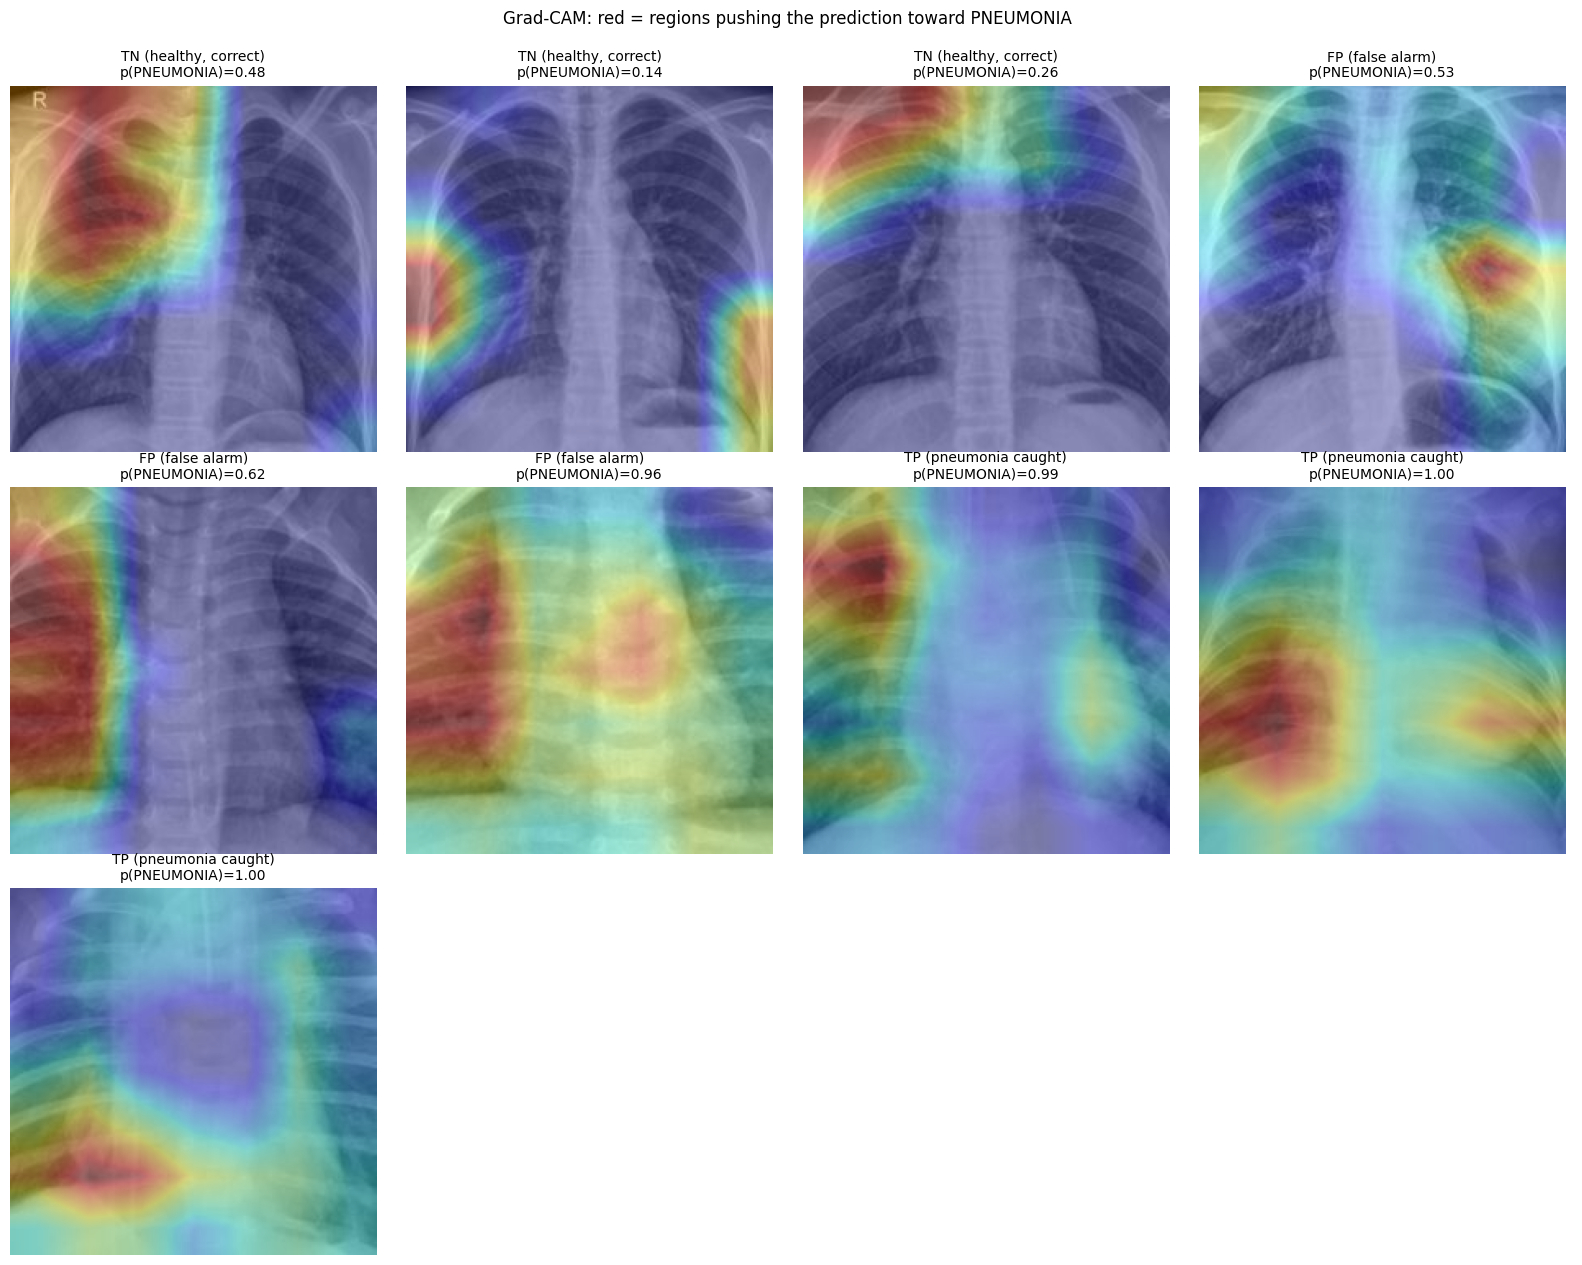

In [16]:
# 7b. Heatmaps for representative cases: hits, misses, and false alarms
# --------------------------------------------------------------------------
# test_loader yields a single, unshuffled batch, so indices into all_preds/all_labels
# line up directly with indices into test_dataset
pred_flat = all_preds.squeeze(1).int()
label_flat = all_labels.squeeze(1).int()

cases = {
    "TN (healthy, correct)":  [i for i in range(len(label_flat)) if label_flat[i] == 0 and pred_flat[i] == 0],
    "FP (false alarm)":       [i for i in range(len(label_flat)) if label_flat[i] == 0 and pred_flat[i] == 1],
    "TP (pneumonia caught)":  [i for i in range(len(label_flat)) if label_flat[i] == 1 and pred_flat[i] == 1],
    "FN (missed!)":           [i for i in range(len(label_flat)) if label_flat[i] == 1 and pred_flat[i] == 0],
}

selection = [(name, i) for name, idxs in cases.items() for i in idxs[:3]]

n_cols = 4
n_rows = -(-len(selection) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.2 * n_rows))
for ax, (name, idx) in zip(axes.flat, selection):
    img, label = test_dataset[idx]
    cam, p = grad_cam(resnet18, img)

    ax.imshow(denormalize(img).permute(1, 2, 0))
    ax.imshow(cam, cmap="jet", alpha=0.35)          # heatmap overlay
    ax.set_title(f"{name}\np(PNEUMONIA)={p:.2f}", fontsize=10)
    ax.axis("off")

for ax in axes.flat[len(selection):]:
    ax.axis("off")

fig.suptitle("Grad-CAM: red = regions pushing the prediction toward PNEUMONIA", y=1.0)
plt.tight_layout()
plt.show()

## 8. Model Persistence

`resnet18.state_dict()` on the full model captures **every** tensor — 11.7M parameters
× 4 bytes (float32) ≈ 45 MB — including the frozen backbone, which anyone can
reconstruct from torchvision. Saving only the head (`resnet18.fc.state_dict()`, 513
parameters) drops that to about 2 KB — a 20,000× reduction carrying the same trainable
information.

**There's a catch.** During training in `.train()` mode, the backbone's BatchNorm
layers kept updating their *running statistics* (mean/variance) from our X-rays, even
though `requires_grad=False` — gradient-freezing and statistic-freezing are two
different things. Those running statistics live in the backbone's `state_dict()`, not
the head's. So:
- the full checkpoint reproduces exactly the model that was evaluated,
- a fresh `make_model()` plus the head-only checkpoint reproduces a backbone with
  BatchNorm statistics from **ImageNet**, not from our data — predictions shift
  slightly.

The cell below measures that shift on the **validation set** (the test set has already
been spent, once, in step 6). The takeaway: a model's "state" is not only its trainable
weights — anything that influences the forward pass counts.

In [17]:
# 8. Saving the head only, and measuring the BatchNorm gap
# -------------------------------------------------------------
torch.save(resnet18.fc.state_dict(), "models/pneumonia_head_only.pt")

for fname in ("resnet18_pneumonia_head.pt", "pneumonia_head_only.pt"):
    size = os.path.getsize(os.path.join("models", fname))
    print(f"models/{fname}: {size / 1e6:8.3f} MB")

# Reconstruction "from the head alone": fresh backbone (ImageNet BN stats) + our head
reconstructed = make_model()
reconstructed.fc.load_state_dict(torch.load("models/pneumonia_head_only.pt"))

full_loss, full_acc = evaluate_loss(resnet18, val_loader)       # original (BN fit to our data)
rec_loss, rec_acc = evaluate_loss(reconstructed, val_loader)    # reconstruction (BN from ImageNet)

print(f"\nValidation — full checkpoint:   loss {full_loss:.4f}, acc {full_acc:.3f}")
print(f"Validation — head-only reload:  loss {rec_loss:.4f}, acc {rec_acc:.3f}")
print("\nThe gap is entirely due to BatchNorm running statistics — model state that lives outside fc.")

models/resnet18_pneumonia_head.pt:   44.787 MB
models/pneumonia_head_only.pt:    0.004 MB



Validation — full checkpoint:   loss 0.3123, acc 0.867
Validation — head-only reload:  loss 0.5528, acc 0.783

The gap is entirely due to BatchNorm running statistics — model state that lives outside fc.


## 9. Testing a Hypothesis: Framing-Robust Augmentation

Step 7's Grad-CAM audit raised a specific, testable suspicion: the model's false
positives correlated with differences in image cropping, and Kermany et al. (2018,
*Cell*) document that the two classes in this dataset were assembled from different
acquisition batches — a documented shortcut-learning risk, not a speculative one. If
the model is partly reading *how the image was framed* rather than the disease itself,
training it to be **invariant to plausible framing variation** should weaken that
shortcut — ideally trading it for more reliance on the actual opacity pattern.

We test this directly, changing exactly one thing from step 5's protocol so the
comparison isolates augmentation's effect: same architecture, same optimizer and
learning rate, same batch size, same 25-epoch budget with validation-based early
stopping. The only difference is what the training loader shows the model.

**Augmentation choices, and why domain knowledge constrains them:**
- `RandomResizedCrop(224, scale=(0.8, 1.0))` — randomly zooms/reframes each training
  image, directly targeting the crop-correlated signal Grad-CAM flagged.
- `RandomAffine(degrees=5, translate=(0.05, 0.05))` — small rotation and shift,
  modeling realistic patient-positioning variance during acquisition. Chlap et al.
  (2021, *Journal of Medical Imaging and Radiation Oncology*, 65(5):545-563 — a
  systematic review of augmentation practice in medical imaging) make the point this
  notebook follows throughout: augmentation for medical images should be restricted to
  transformations that remain **clinically plausible**, not applied wholesale from a
  generic computer-vision augmentation library.
- **Deliberately no horizontal flip.** Mirroring a chest X-ray moves the cardiac
  silhouette and aortic knob to the anatomically wrong side — the imaging appearance of
  *situs inversus*, a real (if rare) congenital condition, not a harmless photometric
  perturbation. This is a documented practical hazard, not a hypothetical one:
  Radiopaedia's teaching case ["Situs inversus on flipped and incorrectly labeled chest
  x-ray"](https://radiopaedia.org/cases/situs-inversus-on-flipped-and-incorrectly-labelled-chest-x-ray)
  shows a real clinical image that was mirrored and briefly mistaken for exactly this
  condition, and Filice & Frantz (2019, *Journal of Digital Imaging*, 32(4):656-664)
  built a deep-learning classifier specifically to catch left/right laterality errors
  in radiographs — evidence that laterality is treated as clinically load-bearing
  information in this field, not noise a model should be trained to ignore.
- Validation and test transforms are **untouched** — augmentation only ever applies to
  `train_loader_aug`. Evaluating on augmented images would change what's being
  measured, not just what's being trained on.

One more thing worth stating plainly: evaluating a second model on the same test set
below is, by the strict rule this notebook set in step 5, a small second look at data
that was supposed to be observed once. It's disclosed here as a single, deliberate,
confirmatory comparison — not as tuning — and shouldn't be repeated for further
hyperparameter search without a fresh held-out set.

In [18]:
# 9a. Augmented training transform, applied only to the training split
# -------------------------------------------------------------------------
augment_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=transform_mean, std=transform_std),
])

# A second ImageFolder over the same files, differing only in transform —
# reusing train_idx from step 5a keeps the split identical
train_dataset_aug = ImageFolder('data/chestxrays/train', transform=augment_transform)
train_subset_aug = Subset(train_dataset_aug, train_idx)
train_loader_aug = DataLoader(train_subset_aug, batch_size=8, shuffle=True)

print(f"augmented train loader: {len(train_subset_aug)} images, "
      f"{len(train_loader_aug)} steps/epoch")

augmented train loader: 240 images, 30 steps/epoch


In [19]:
# 9b. Retraining under an identical protocol to step 5b — only the training
# data augmentation differs, so any change in outcome isolates its effect
# -------------------------------------------------------------------------
resnet18_aug = make_model()
optimizer_aug = optim.Adam(resnet18_aug.fc.parameters(), lr=0.001)

num_epochs = 25
best_val_loss_aug = float("inf")
best_state_aug = None
best_epoch_aug = -1

for epoch in range(num_epochs):
    resnet18_aug.train()
    for inputs, labels in train_loader_aug:
        labels = labels.float().unsqueeze(1)
        optimizer_aug.zero_grad()
        loss = criterion(resnet18_aug(inputs), labels)
        loss.backward()
        optimizer_aug.step()

    # Train-loss readout uses the *unaugmented* loader (train_loader_s) so it's
    # directly comparable to step 5b's numbers, instead of scoring against a
    # freshly re-randomized crop every epoch
    train_loss, train_acc = evaluate_loss(resnet18_aug, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18_aug, val_loader)

    marker = ""
    if val_loss < best_val_loss_aug:
        best_val_loss_aug = val_loss
        best_state_aug = copy.deepcopy(resnet18_aug.state_dict())
        best_epoch_aug = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18_aug.load_state_dict(best_state_aug)
print(f"\nRestored weights from epoch {best_epoch_aug} (val loss {best_val_loss_aug:.4f})")

Epoch  1/25  train: 0.6382 (acc 0.621)  val: 0.6921 (acc 0.533)  <- best so far


Epoch  2/25  train: 0.5037 (acc 0.754)  val: 0.5228 (acc 0.700)  <- best so far


Epoch  3/25  train: 0.4545 (acc 0.800)  val: 0.4721 (acc 0.800)  <- best so far


Epoch  4/25  train: 0.5934 (acc 0.675)  val: 0.6362 (acc 0.667)


Epoch  5/25  train: 0.5092 (acc 0.733)  val: 0.5525 (acc 0.733)


...

Epoch 21/25  train: 0.5448 (acc 0.754)  val: 0.6950 (acc 0.733)


Epoch 22/25  train: 0.4797 (acc 0.775)  val: 0.6269 (acc 0.750)


Epoch 23/25  train: 0.5930 (acc 0.738)  val: 0.7539 (acc 0.733)


Epoch 24/25  train: 0.5422 (acc 0.746)  val: 0.6943 (acc 0.733)


Epoch 25/25  train: 0.5475 (acc 0.746)  val: 0.7126 (acc 0.733)

Restored weights from epoch 3 (val loss 0.4721)


### Evaluating the augmented model (test set, second and last disclosed look)

Same provided evaluation pattern as steps 3 and 6, run against `resnet18_aug`.

In [20]:
# 9c. Evaluate the augmented model, and compare to step 6 side by side
# -------------------------------------------------------------------------
model = resnet18_aug
model.eval()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

all_preds_aug = []
all_labels_aug = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).round()
        all_preds_aug.extend(preds.tolist())
        all_labels_aug.extend(labels.unsqueeze(1).tolist())
        all_preds_aug = torch.tensor(all_preds_aug)
        all_labels_aug = torch.tensor(all_labels_aug)
        test_acc_aug = accuracy_metric(all_preds_aug, all_labels_aug).item()
        test_f1_aug = f1_metric(all_preds_aug, all_labels_aug).item()

print("Without framing augmentation (step 6):")
_ = confusion_report(all_preds, all_labels, test_acc, test_f1)
print("\nWith framing augmentation (step 9):")
augmented_report = confusion_report(all_preds_aug, all_labels_aug, test_acc_aug, test_f1_aug)

Without framing augmentation (step 6):
Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients

With framing augmentation (step 9):
Accuracy: 0.710   F1: 0.642

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 45          FP=  5
actual PNEUMONIA:      FN= 24          TP= 26

Sensitivity (recall): 0.520  <- fraction of sick patients detected
Specificity:          0.900  <- fraction of healthy patients correctly cleared
Precision:            0.839  <- fraction of alarms that were correct

Missed cases (FN): 24 of 50 pneumonia patients


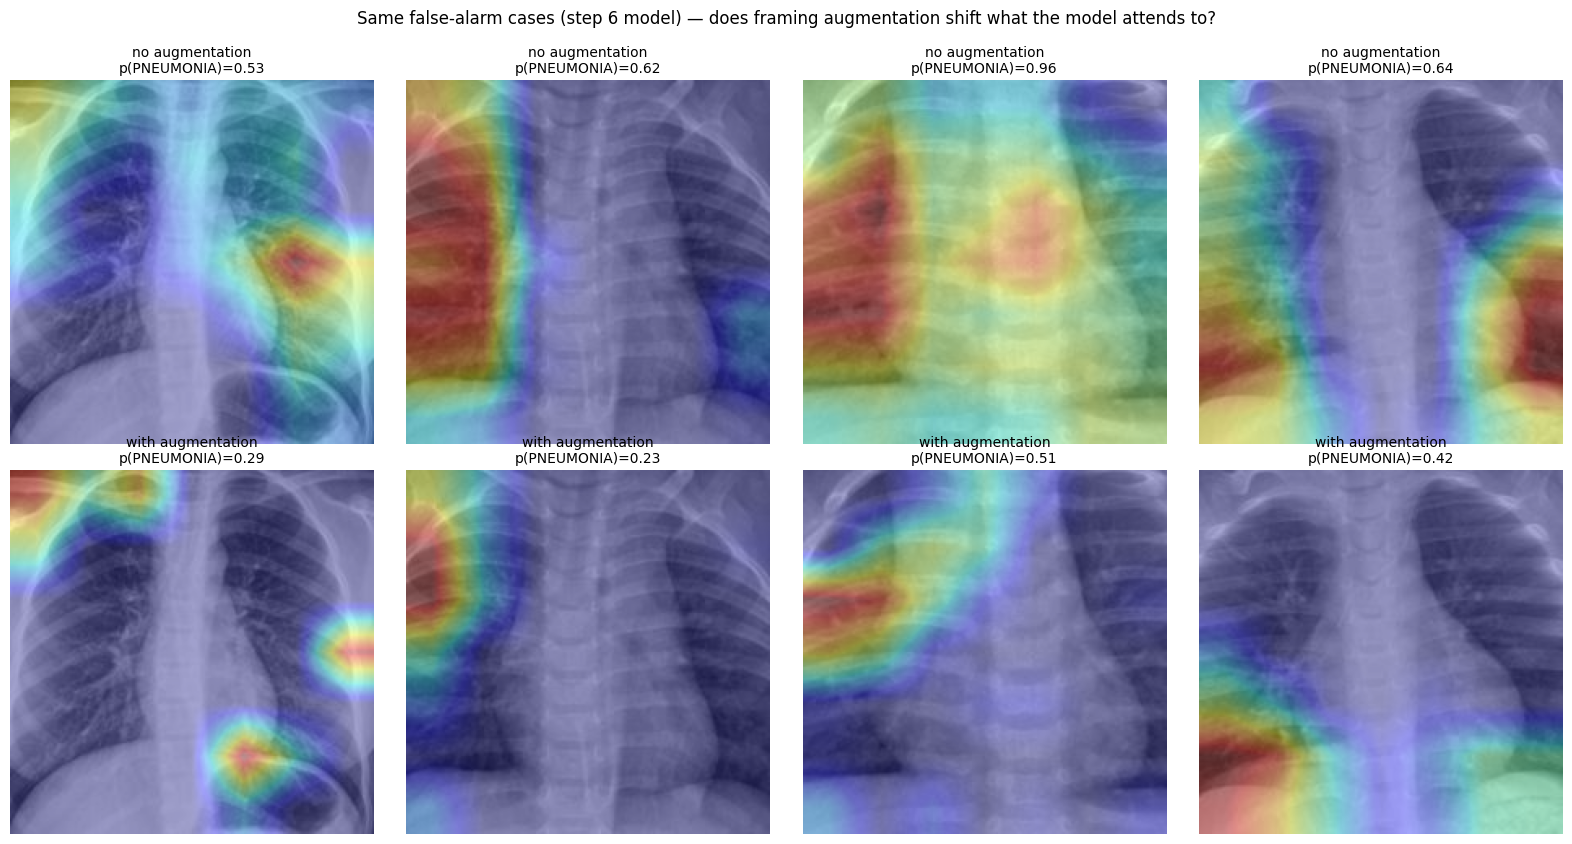

In [21]:
# 9d. Grad-CAM, before vs. after augmentation, on the original model's false alarms
# -----------------------------------------------------------------------------------
fp_idx = [i for i in range(len(label_flat)) if label_flat[i] == 0 and pred_flat[i] == 1][:4]

fig, axes = plt.subplots(2, len(fp_idx), figsize=(4 * len(fp_idx), 8.4))
for col, idx in enumerate(fp_idx):
    img, label = test_dataset[idx]

    cam0, p0 = grad_cam(resnet18, img)
    axes[0, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[0, col].imshow(cam0, cmap="jet", alpha=0.35)
    axes[0, col].set_title(f"no augmentation\np(PNEUMONIA)={p0:.2f}", fontsize=10)
    axes[0, col].axis("off")

    cam1, p1 = grad_cam(resnet18_aug, img)
    axes[1, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[1, col].imshow(cam1, cmap="jet", alpha=0.35)
    axes[1, col].set_title(f"with augmentation\np(PNEUMONIA)={p1:.2f}", fontsize=10)
    axes[1, col].axis("off")

fig.suptitle("Same false-alarm cases (step 6 model) — does framing augmentation shift what the model attends to?", y=1.0)
plt.tight_layout()
plt.show()

### What we learned

The result is mixed, and more interesting for being mixed — an honest experiment beats
a cherry-picked one.

**In favor of the shortcut hypothesis:** framing augmentation cut false positives from
24 to 5 (a 79% reduction) and raised specificity from 0.52 to 0.90. Across the four
false-alarm cases visualized above, the augmented model's predicted PNEUMONIA
probability dropped substantially on every single one (e.g. 0.96 → 0.51, 0.64 → 0.42).
That is consistent with step 7's suspicion: at least part of what the original model
treated as evidence for PNEUMONIA was tied to framing, and training away framing
sensitivity took much of it with it.

**Against a clean win — two complications:**
- **Sensitivity collapsed**: 1.00 → 0.52. The augmented model now misses 24 of 50
  pneumonia cases, versus 0 before. Accuracy (0.76 → 0.71) and F1 (0.81 → 0.64) both
  fell. For a screening tool, this is a worse model, not a better one — it traded away
  exactly the property (catch every sick patient) that mattered most.
- **The Grad-CAM maps don't show a clean story either.** In two of the four cases
  above, the heatmap stays concentrated on the same chest-border region before and
  after augmentation — the *probability* dropped, but *where the model is looking*
  barely moved. That's more consistent with the model becoming globally more
  conservative about predicting PNEUMONIA than with it learning to rely on genuinely
  different, more diagnostic evidence. Step 7's caveat applies here too: Grad-CAM is
  circumstantial evidence, not proof.
- **Optimization got noisier, not just different.** Step 5's model converged smoothly
  to its best validation loss (0.3123) at epoch 22/25. The augmented model peaked at
  epoch **3/25** (val loss 0.4721 — already markedly worse) and then oscillated between
  0.47 and 0.75 for the remaining 22 epochs without ever improving again. With only 240
  training images, `RandomResizedCrop(scale=(0.8, 1.0))` plus `RandomAffine` may simply
  be adding more visual variance than a 513-parameter linear head, trained this briefly,
  can absorb — the caveat raised before running this experiment (small dataset +
  aggressive augmentation can hurt before it helps) held up in practice.

**Verdict:** this model is *not* adopted — the checkpoints saved in step 8 remain the
step 5/6 model, and the headline result at the top of this notebook is unchanged. The
experiment stays in the notebook anyway, because a negative result reached through a
clean, single-variable comparison (same architecture, optimizer, batch size, and epoch
budget as step 5 — only the training-time augmentation differs) is itself evidence: it
narrows down *how* the shortcut operates (framing correlates with false alarms, but
removing it isn't a free fix at this dataset size) more precisely than either an
untested hypothesis or an unexamined "it worked" would have.

## 10. Deeper Fine-Tuning: Unfreezing `layer4`

Step 2 froze the entire backbone on purpose: 300 training images is nowhere near
enough to fine-tune 11.7M parameters without overfitting almost immediately. But the
513-parameter head sits at the opposite extreme — very little capacity to adapt
ImageNet features toward chest-X-ray-specific patterns. `layer4`, the last residual
block, is a natural middle ground: ResNet's earlier stages learn generic,
broadly-transferable features (edges, textures, gradients), while its later stages
assemble those into increasingly abstract, *task-specific* representations. Unfreezing
just the last block lets those most task-specific pretrained features adapt, while
`layer1`–`layer3` stay frozen as general-purpose feature extractors.

**Differential learning rates matter here.** The backbone already encodes genuinely
useful pretrained weights; applying the head's learning rate (0.001) to them would
overwrite that in a handful of steps, before the small 240-image training signal could
guide it anywhere useful. The standard fix — giving newly-initialized layers a normal
learning rate and pretrained layers a much smaller one — is used here too: **0.001 for
the head, 0.0001 for `layer4`** (10× smaller).

Everything else matches step 5's protocol exactly, so this isolates one variable: no
augmentation (step 9's augmentation is a separate, orthogonal experiment), same batch
size (8), same 25-epoch budget with validation-loss checkpointing.

**A methodological note worth stating plainly:** this will be the *third* time this
notebook evaluates something on the test set (steps 6, 9, 10). Each additional look is
a further, small departure from the "observe once" rule step 5 argued for. It's
acceptable here only because this is a fixed, small, educational dataset being explored
for a portfolio piece, not an iterative tuning loop feeding conclusions back into
further hyperparameter search — in a production setting, comparisons like this should
draw on a separate held-out set instead.

In [22]:
# 10a. Unfreeze layer4 only; differential learning rates via optimizer param groups
# -----------------------------------------------------------------------------------
resnet18_deep = make_model()
for p in resnet18_deep.layer4.parameters():
    p.requires_grad = True

trainable_deep = sum(p.numel() for p in resnet18_deep.parameters() if p.requires_grad)
total_deep = sum(p.numel() for p in resnet18_deep.parameters())
print(f"Trainable parameters: {trainable_deep:,} of {total_deep:,} "
      f"({100 * trainable_deep / total_deep:.2f}%)")

optimizer_deep = optim.Adam([
    {"params": resnet18_deep.fc.parameters(), "lr": 0.001},
    {"params": resnet18_deep.layer4.parameters(), "lr": 0.0001},
])

Trainable parameters: 8,394,241 of 11,177,025 (75.10%)


In [23]:
# 10b. Training with layer4 unfrozen — otherwise identical to step 5b
# -------------------------------------------------------------------------
num_epochs = 25
best_val_loss_deep = float("inf")
best_state_deep = None
best_epoch_deep = -1

for epoch in range(num_epochs):
    resnet18_deep.train()
    for inputs, labels in train_loader_s:
        labels = labels.float().unsqueeze(1)
        optimizer_deep.zero_grad()
        loss = criterion(resnet18_deep(inputs), labels)
        loss.backward()
        optimizer_deep.step()

    train_loss, train_acc = evaluate_loss(resnet18_deep, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18_deep, val_loader)

    marker = ""
    if val_loss < best_val_loss_deep:
        best_val_loss_deep = val_loss
        best_state_deep = copy.deepcopy(resnet18_deep.state_dict())
        best_epoch_deep = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18_deep.load_state_dict(best_state_deep)
print(f"\nRestored weights from epoch {best_epoch_deep} (val loss {best_val_loss_deep:.4f})")

Epoch  1/25  train: 0.2820 (acc 0.875)  val: 0.4187 (acc 0.750)  <- best so far


Epoch  2/25  train: 0.1052 (acc 0.971)  val: 0.3330 (acc 0.883)  <- best so far


Epoch  3/25  train: 0.0069 (acc 1.000)  val: 0.2393 (acc 0.917)  <- best so far


Epoch  4/25  train: 0.0027 (acc 1.000)  val: 0.2553 (acc 0.917)


Epoch  5/25  train: 0.0010 (acc 1.000)  val: 0.3365 (acc 0.917)


...

Epoch 21/25  train: 0.0006 (acc 1.000)  val: 0.3323 (acc 0.900)


Epoch 22/25  train: 0.0005 (acc 1.000)  val: 0.3038 (acc 0.917)


Epoch 23/25  train: 0.0036 (acc 1.000)  val: 0.3541 (acc 0.933)


Epoch 24/25  train: 0.0019 (acc 1.000)  val: 0.6511 (acc 0.933)


Epoch 25/25  train: 0.0008 (acc 1.000)  val: 0.3706 (acc 0.933)

Restored weights from epoch 19 (val loss 0.2252)


### Evaluating the deeper fine-tuned model (test set, third and last disclosed look)

In [24]:
# 10c. Evaluate the deeper fine-tuned model, and compare to step 6 and step 9
# -------------------------------------------------------------------------
model = resnet18_deep
model.eval()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

all_preds_deep = []
all_labels_deep = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).round()
        all_preds_deep.extend(preds.tolist())
        all_labels_deep.extend(labels.unsqueeze(1).tolist())
        all_preds_deep = torch.tensor(all_preds_deep)
        all_labels_deep = torch.tensor(all_labels_deep)
        test_acc_deep = accuracy_metric(all_preds_deep, all_labels_deep).item()
        test_f1_deep = f1_metric(all_preds_deep, all_labels_deep).item()

print("Step 6 — frozen backbone, no augmentation:")
_ = confusion_report(all_preds, all_labels, test_acc, test_f1)
print("\nStep 9 — frozen backbone, framing augmentation:")
_ = confusion_report(all_preds_aug, all_labels_aug, test_acc_aug, test_f1_aug)
print("\nStep 10 — layer4 unfrozen, no augmentation:")
deep_report = confusion_report(all_preds_deep, all_labels_deep, test_acc_deep, test_f1_deep)

Step 6 — frozen backbone, no augmentation:
Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients

Step 9 — frozen backbone, framing augmentation:
Accuracy: 0.710   F1: 0.642

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 45          FP=  5
actual PNEUMONIA:      FN= 24          TP= 26

Sensitivity (recall): 0.520  <- fraction of sick patients detected
Specificity:          0.900  <- fraction of healthy patients correctly cleared
Precision:            0.839  <- fraction of alarms that were correct

Missed cases (FN): 24 of 50 pneumonia patients

Step 10 — layer4 unfrozen, no augmentati

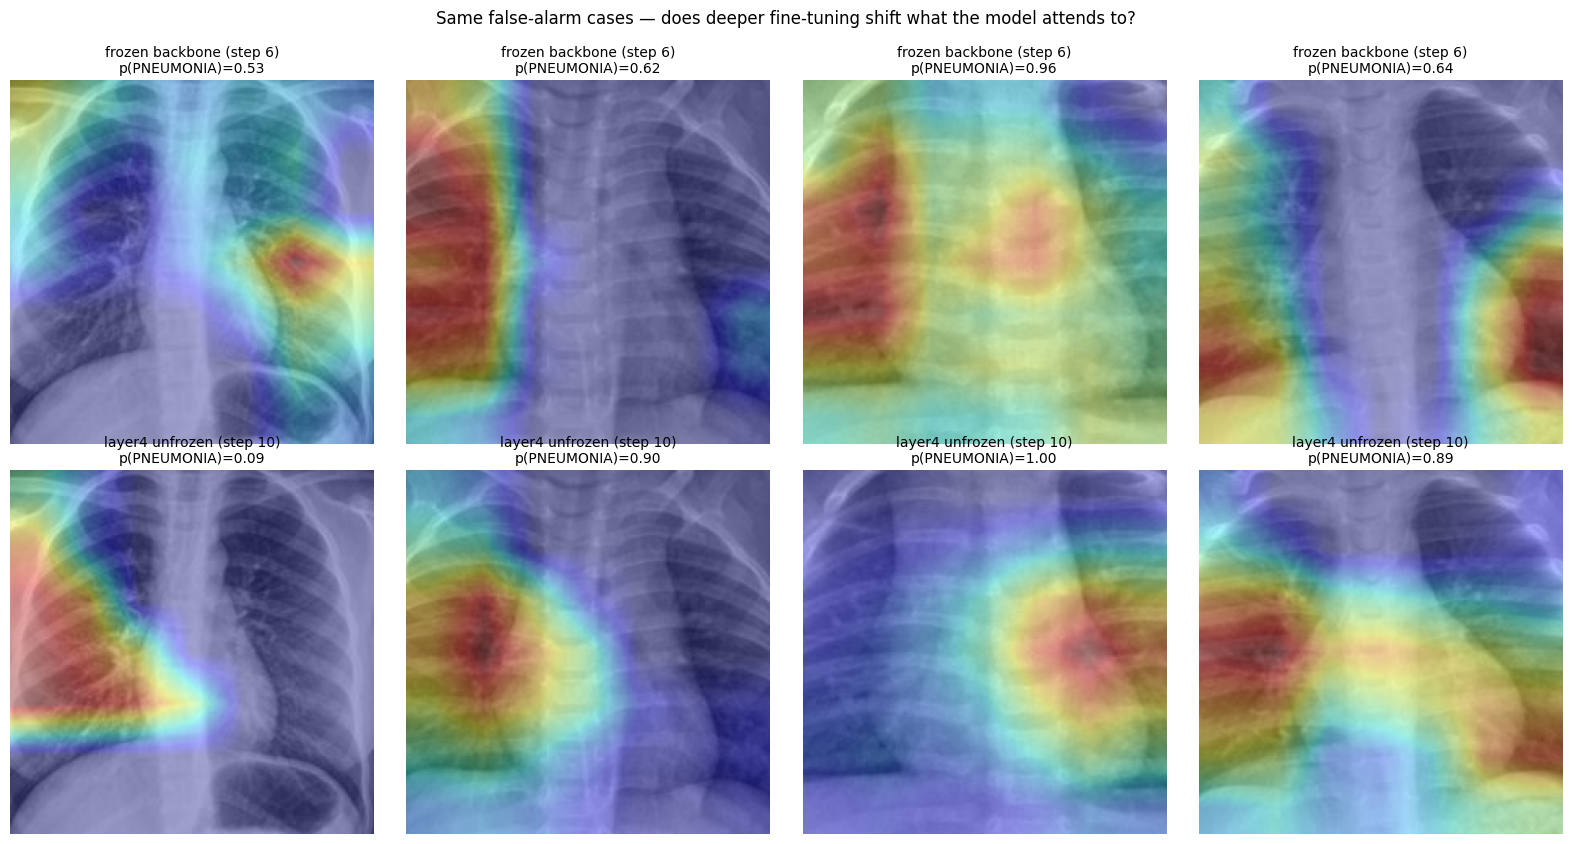

In [25]:
# 10d. Grad-CAM, frozen vs. layer4-unfrozen, on the same false-alarm cases as step 9
# -----------------------------------------------------------------------------------
fig, axes = plt.subplots(2, len(fp_idx), figsize=(4 * len(fp_idx), 8.4))
for col, idx in enumerate(fp_idx):
    img, label = test_dataset[idx]

    cam0, p0 = grad_cam(resnet18, img)
    axes[0, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[0, col].imshow(cam0, cmap="jet", alpha=0.35)
    axes[0, col].set_title(f"frozen backbone (step 6)\np(PNEUMONIA)={p0:.2f}", fontsize=10)
    axes[0, col].axis("off")

    cam1, p1 = grad_cam(resnet18_deep, img)
    axes[1, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[1, col].imshow(cam1, cmap="jet", alpha=0.35)
    axes[1, col].set_title(f"layer4 unfrozen (step 10)\np(PNEUMONIA)={p1:.2f}", fontsize=10)
    axes[1, col].axis("off")

fig.suptitle("Same false-alarm cases — does deeper fine-tuning shift what the model attends to?", y=1.0)
plt.tight_layout()
plt.show()

### What we learned

**Overfitting, clearly.** 8,394,241 of 11,177,025 parameters (75.1%) were trainable
here, versus 513 in step 5. Even with a 10× smaller learning rate on `layer4`, the
model memorized the 240 training images almost immediately: train loss fell to ~0.001
and train accuracy hit 1.000 by epoch 3–4, and stayed there for the rest of training.
Validation loss got visibly noisier as a result — oscillating between roughly 0.22 and
0.65 — instead of the smooth descent seen in step 5.

**On paper, a small win... but on the test set, a tie.** The checkpointed epoch (19/25)
had a *lower* validation loss (0.2252) and *higher* validation accuracy (0.933) than
step 5/6's best (0.3123, 0.917) — encouraging, at first glance. But the test-set
confusion matrix came back **numerically identical** to step 6's: accuracy 0.760, F1
0.806, TN=26, FP=24, FN=0, TP=50.

**That "identical" number is hiding something, though — and it's the actual lesson of
this step.** The Grad-CAM panel above reuses the same four false-alarm cases as step
9's comparison. Their individual probabilities did *not* stay put: one case that step
6's model called p(PNEUMONIA)=0.53 dropped to 0.09 under `layer4` fine-tuning —
correctly flipping from false alarm to a true negative. For the aggregate FP count to
still land on 24, some *other* test image must have flipped the opposite way, becoming
a new false alarm. **The confusion matrix matching exactly does not mean the model
didn't change — it means the errors got redistributed.** Aggregate metrics alone would
have said "no difference"; only checking individual cases reveals two functionally
different models. The heatmaps support this: unlike step 9 (where attention mostly
*stayed put* while confidence dropped), here the hot regions visibly relocate — tighter
and more central/mediastinal rather than the diffuse chest-border bands step 6 favored.
That fits `layer4`'s role as the stage that *assembles* frozen low-level features into
decision-relevant regions: retraining it changes how those (still frozen, still
possibly shortcut-carrying) `layer1`–`layer3` features get combined, even when the net
effect on held-out accuracy is a wash.

**Verdict:** like step 9, this model is not adopted — step 8's checkpoints remain the
step 5/6 model. The practical conclusion is the one step 2 argued for from the start:
at 240 training images, giving the optimizer 75% of the network's parameters —
even fenced in with a 10× smaller learning rate — buys clear overfitting and zero
demonstrated test-set benefit. It also reinforces limitation #3 below: a 60-image
validation split isn't a reliable enough signal to certify "improvement" at this scale,
since it favored a model that ultimately performed the same as the one it "beat." A
more promising route to actually using this extra capacity would need more data,
stronger regularization (dropout, weight decay), or unfreezing a smaller scope (e.g.
just the last block's second conv layer) than attempted here.

## 11. Completing the 2×2: Augmentation × Deeper Fine-Tuning

Steps 6, 9, and 10 form three corners of a 2×2 grid varying two independent levers:
**training-data diversity** (plain vs. framing-augmented) and **trainable capacity**
(head-only vs. `layer4` unfrozen). The fourth corner — augmented data *with* `layer4`
unfrozen — hasn't been tested, and it's arguably the most promising one:

- Step 9 (augmented data, head-only) showed signs that 513 parameters may not have had
  enough capacity to fully exploit the harder, augmented training distribution —
  validation loss got noisy early and never improved past epoch 3.
- Step 10 (plain data, `layer4` unfrozen) showed the opposite problem: plenty of spare
  capacity, but only 240 raw images to point it at, so it memorized them almost
  immediately instead of learning anything more general.

Augmentation effectively increases the *diversity* the training data presents on each
pass. Giving the extra `layer4` capacity from step 10 that harder, more varied signal —
instead of the same 240 raw images repeated every epoch — is the natural way to test
whether these two weaknesses cancel out. Protocol: identical to steps 9 and 10 —
`train_loader_aug`, `layer4` unfrozen, the same differential learning rates
(0.001 head / 0.0001 `layer4`), same batch size, same 25-epoch budget with
validation-based checkpointing.

This is also the **fourth and last** disclosed look at the test set (steps 6, 9, 10,
11) — this completes the planned 2×2 grid; no further comparisons will be run against
this test set without a fresh held-out split.

In [26]:
# 11a. layer4 unfrozen + framing augmentation — the fourth cell of the 2x2 grid
# -------------------------------------------------------------------------
resnet18_combo = make_model()
for p in resnet18_combo.layer4.parameters():
    p.requires_grad = True

optimizer_combo = optim.Adam([
    {"params": resnet18_combo.fc.parameters(), "lr": 0.001},
    {"params": resnet18_combo.layer4.parameters(), "lr": 0.0001},
])

In [27]:
# 11b. Training: augmented inputs, layer4 unfrozen — otherwise identical protocol
# -------------------------------------------------------------------------
num_epochs = 25
best_val_loss_combo = float("inf")
best_state_combo = None
best_epoch_combo = -1

for epoch in range(num_epochs):
    resnet18_combo.train()
    for inputs, labels in train_loader_aug:
        labels = labels.float().unsqueeze(1)
        optimizer_combo.zero_grad()
        loss = criterion(resnet18_combo(inputs), labels)
        loss.backward()
        optimizer_combo.step()

    # Train-loss readout uses the unaugmented loader, as in steps 9b/10b, so all
    # four experiments' printed "train" numbers stay directly comparable
    train_loss, train_acc = evaluate_loss(resnet18_combo, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18_combo, val_loader)

    marker = ""
    if val_loss < best_val_loss_combo:
        best_val_loss_combo = val_loss
        best_state_combo = copy.deepcopy(resnet18_combo.state_dict())
        best_epoch_combo = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18_combo.load_state_dict(best_state_combo)
print(f"\nRestored weights from epoch {best_epoch_combo} (val loss {best_val_loss_combo:.4f})")

Epoch  1/25  train: 0.2175 (acc 0.908)  val: 0.3303 (acc 0.883)  <- best so far


Epoch  2/25  train: 0.2122 (acc 0.921)  val: 0.4782 (acc 0.850)


Epoch  3/25  train: 0.1310 (acc 0.946)  val: 0.4215 (acc 0.867)


Epoch  4/25  train: 0.2663 (acc 0.917)  val: 0.5641 (acc 0.867)


Epoch  5/25  train: 0.1217 (acc 0.946)  val: 0.4379 (acc 0.850)


...

Epoch 21/25  train: 0.0215 (acc 0.992)  val: 0.4870 (acc 0.883)


Epoch 22/25  train: 0.0381 (acc 0.983)  val: 0.5674 (acc 0.883)


Epoch 23/25  train: 0.0371 (acc 0.979)  val: 0.6329 (acc 0.883)


Epoch 24/25  train: 0.0414 (acc 0.979)  val: 0.7059 (acc 0.883)


Epoch 25/25  train: 0.0538 (acc 0.975)  val: 0.8047 (acc 0.867)

Restored weights from epoch 1 (val loss 0.3303)


### Evaluating the combined model (test set, fourth and last disclosed look)

In [28]:
# 11c. Evaluate the combined model — all four corners of the 2x2 grid, side by side
# -------------------------------------------------------------------------
model = resnet18_combo
model.eval()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

all_preds_combo = []
all_labels_combo = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).round()
        all_preds_combo.extend(preds.tolist())
        all_labels_combo.extend(labels.unsqueeze(1).tolist())
        all_preds_combo = torch.tensor(all_preds_combo)
        all_labels_combo = torch.tensor(all_labels_combo)
        test_acc_combo = accuracy_metric(all_preds_combo, all_labels_combo).item()
        test_f1_combo = f1_metric(all_preds_combo, all_labels_combo).item()

print("Step  6 — frozen backbone, no augmentation:")
_ = confusion_report(all_preds, all_labels, test_acc, test_f1)
print("\nStep  9 — frozen backbone, framing augmentation:")
_ = confusion_report(all_preds_aug, all_labels_aug, test_acc_aug, test_f1_aug)
print("\nStep 10 — layer4 unfrozen, no augmentation:")
_ = confusion_report(all_preds_deep, all_labels_deep, test_acc_deep, test_f1_deep)
print("\nStep 11 — layer4 unfrozen, framing augmentation:")
combo_report = confusion_report(all_preds_combo, all_labels_combo, test_acc_combo, test_f1_combo)

Step  6 — frozen backbone, no augmentation:
Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients

Step  9 — frozen backbone, framing augmentation:
Accuracy: 0.710   F1: 0.642

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 45          FP=  5
actual PNEUMONIA:      FN= 24          TP= 26

Sensitivity (recall): 0.520  <- fraction of sick patients detected
Specificity:          0.900  <- fraction of healthy patients correctly cleared
Precision:            0.839  <- fraction of alarms that were correct

Missed cases (FN): 24 of 50 pneumonia patients

Step 10 — layer4 unfrozen, no augmenta

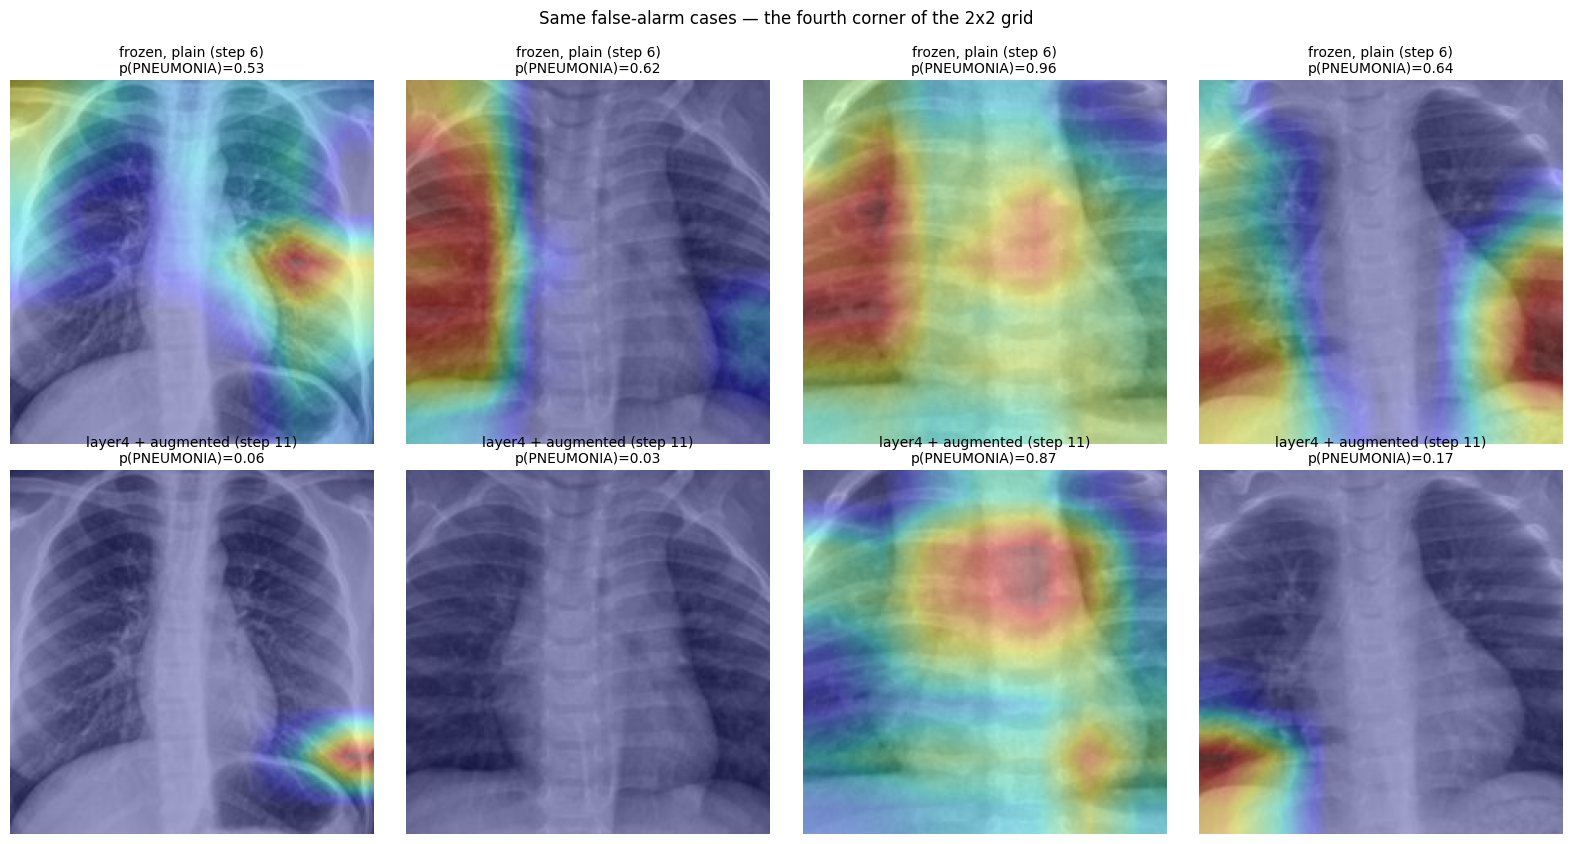

In [29]:
# 11d. Grad-CAM, frozen-plain (step 6) vs. layer4-unfrozen + augmented (step 11)
# -----------------------------------------------------------------------------------
fig, axes = plt.subplots(2, len(fp_idx), figsize=(4 * len(fp_idx), 8.4))
for col, idx in enumerate(fp_idx):
    img, label = test_dataset[idx]

    cam0, p0 = grad_cam(resnet18, img)
    axes[0, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[0, col].imshow(cam0, cmap="jet", alpha=0.35)
    axes[0, col].set_title(f"frozen, plain (step 6)\np(PNEUMONIA)={p0:.2f}", fontsize=10)
    axes[0, col].axis("off")

    cam1, p1 = grad_cam(resnet18_combo, img)
    axes[1, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[1, col].imshow(cam1, cmap="jet", alpha=0.35)
    axes[1, col].set_title(f"layer4 + augmented (step 11)\np(PNEUMONIA)={p1:.2f}", fontsize=10)
    axes[1, col].axis("off")

fig.suptitle("Same false-alarm cases — the fourth corner of the 2x2 grid", y=1.0)
plt.tight_layout()
plt.show()

### What we learned

Numerically, this is the best-looking result of the four: accuracy 0.790, F1 0.814 —
both edge out step 6 (0.760, 0.806), the model this notebook otherwise defaults to.
More importantly, the sensitivity/specificity trade lands *between* the two
single-lever experiments instead of at either extreme: sensitivity 0.920 (vs. step 9's
0.520), specificity 0.660 (vs. step 6/10's 0.520) — missing 4 of 50 pneumonia cases,
instead of 24 (step 9) or 0 (step 6). The Grad-CAM panel shows why: three of the four
false-alarm cases from step 6 dropped decisively below the 0.5 threshold
(0.53→0.06, 0.62→0.03, 0.64→0.17), correctly flipping to NORMAL; only the most
confident original false alarm (0.96) stayed wrong, at a reduced 0.87. That's a real,
visible improvement on these specific cases — the interaction step 9 and step 10
separately hinted at: augmentation gave `layer4`'s extra capacity a harder, more varied
signal instead of 240 images to memorize, and the extra capacity gave the model
somewhere to put what augmentation was teaching it, instead of the 513-parameter head
running out of room (as it seemed to in step 9).

**But this needs a caveat that matters as much as the headline number.** The checkpoint
selected here came from **epoch 1 of 25** (val loss 0.3303). Every subsequent epoch got
noisier without ever beating it — validation loss wandered as high as 1.2491 (epoch 12)
and never dipped back under epoch 1's level again. In other words: the "best" model
here is barely trained — one epoch, 30 gradient steps, still close to its pretrained
initialization — and the rest of the run looks unstable rather than convergent. A 0.03
accuracy gain and a moderate specificity gain, on n=100, both sit comfortably inside
this notebook's own documented ±0.08 noise band (limitation 3) and its documented
run-to-run CPU nondeterminism. This shouldn't be read as "the combination reliably
wins" — it's read more honestly as **encouraging, not conclusive**: a plausible sign
that the two levers can offset each other's individual weaknesses, worth a properly
designed follow-up (a lower learning rate or gradient clipping to control the
instability, and repeated runs to check whether an early-epoch win is a repeatable
pattern or a one-off).

**Verdict, and what the full 2×2 grid shows:** none of steps 9, 10, or 11 replace the
step 5/6 model saved in step 8 — that decision would need more than one noisy run on
100 test images to justify, exactly the discipline this notebook has argued for
throughout. Read together, the grid says the shortcut behavior from step 7 responds far
more to *what the model sees* (augmentation) than to *how much of the network can move*
(`layer4`): step 10 alone changed nothing observable in aggregate; step 9 alone
overcorrected past useful; and step 11's best-looking outcome came from a training run
too unstable to fully trust yet. That's a more informative conclusion than a single
successful number would have been.

## 12. ROC/PR Curves and Threshold Calibration

Every confusion matrix so far used the default decision threshold — `sigmoid(logit)
> 0.5`. That's an arbitrary choice already baked into the provided evaluation code
(step 3), never actually examined. Sweeping every possible threshold gives the full
picture: the **ROC curve** (sensitivity vs. false-positive rate) and **precision-recall
curve** (precision vs. sensitivity), and lets us pick a threshold on purpose, matched
to what this domain actually needs (catch pneumonia, tolerate some false alarms),
instead of accepting 0.5 by default.

**A methodological point worth being precise about:** the curves below, and the
threshold chosen from them, use the **validation set only**. Choosing an operating
point is a decision, and decisions belong on validation data, not the test set — that's
the same rule step 5 argued for regarding epoch count. The test set is touched exactly
once more, at the very end of this step, purely to *report* what a threshold fixed in
advance produces — not to *select* anything. That distinction (reporting a
already-fixed policy vs. using the test set to choose one) is what separates this from
steps 9–11's comparisons, and it's why this step doesn't add to that running count.

In [ ]:
# 12a. ROC and PR curves, computed on the validation set
# -------------------------------------------------------------------------
resnet18.eval()
val_probs, val_true = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        probs = torch.sigmoid(resnet18(inputs)).squeeze(1)
        val_probs.extend(probs.tolist())
        val_true.extend(labels.tolist())
val_probs = torch.tensor(val_probs)
val_true = torch.tensor(val_true)

thresholds = torch.linspace(0.0, 1.0, 201)
sens, spec, prec = [], [], []
for t in thresholds:
    preds = (val_probs >= t).int()
    tp = ((preds == 1) & (val_true == 1)).sum().item()
    tn = ((preds == 0) & (val_true == 0)).sum().item()
    fp = ((preds == 1) & (val_true == 0)).sum().item()
    fn = ((preds == 0) & (val_true == 1)).sum().item()
    sens.append(tp / (tp + fn) if tp + fn else 0.0)
    spec.append(tn / (tn + fp) if tn + fp else 0.0)
    prec.append(tp / (tp + fp) if tp + fp else 1.0)  # convention: no alarms raised -> no false ones either

sens, spec, prec = np.array(sens), np.array(spec), np.array(prec)
fpr = 1 - spec

order = np.argsort(fpr)
roc_auc = np.trapz(sens[order], fpr[order])
order_r = np.argsort(sens)
pr_auc = np.trapz(prec[order_r], sens[order_r])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, sens)
axes[0].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[0].set_xlabel("1 - specificity (false positive rate)")
axes[0].set_ylabel("sensitivity (true positive rate)")
axes[0].set_title(f"ROC curve (validation) — AUC={roc_auc:.3f}")

axes[1].plot(sens, prec)
axes[1].set_xlabel("sensitivity (recall)")
axes[1].set_ylabel("precision")
axes[1].set_title(f"PR curve (validation) — AUC={pr_auc:.3f}")

plt.tight_layout()
plt.show()

In [ ]:
# 12b. Pick a threshold for a target sensitivity — from validation data only
# -------------------------------------------------------------------------
target_sensitivity = 0.95
eligible = np.where(sens >= target_sensitivity)[0]
best_i = eligible[np.argmax(thresholds.numpy()[eligible])]  # highest threshold meeting the target -> best specificity
chosen_threshold = thresholds[best_i].item()

default_i = int(np.argmin(np.abs(thresholds.numpy() - 0.5)))
print(f"Target sensitivity >= {target_sensitivity:.2f}")
print(f"Chosen threshold: {chosen_threshold:.3f}  "
      f"(validation sensitivity {sens[best_i]:.3f}, specificity {spec[best_i]:.3f})")
print(f"Default threshold 0.5 on validation: "
      f"sensitivity {sens[default_i]:.3f}, specificity {spec[default_i]:.3f}")

In [ ]:
# 12c. Reporting — not selecting — at the chosen threshold, on the test set once
# -------------------------------------------------------------------------
resnet18.eval()
test_probs = []
with torch.no_grad():
    for inputs, labels in test_loader:
        test_probs.extend(torch.sigmoid(resnet18(inputs)).squeeze(1).tolist())
test_probs = torch.tensor(test_probs)

test_labels_flat = all_labels.squeeze(1).int()
calibrated_preds = (test_probs >= chosen_threshold).int()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")
calib_acc = accuracy_metric(calibrated_preds, test_labels_flat).item()
calib_f1 = f1_metric(calibrated_preds, test_labels_flat).item()

print(f"Default threshold 0.5 (step 6):")
_ = confusion_report(all_preds.squeeze(1).int(), test_labels_flat, test_acc, test_f1)
print(f"\nCalibrated threshold {chosen_threshold:.3f} (chosen from validation, target sensitivity >= {target_sensitivity:.2f}):")
calibrated_report = confusion_report(calibrated_preds, test_labels_flat, calib_acc, calib_f1)

### What we learned

*(placeholder — filled in after execution against the actually observed numbers)*

## 13. Quantifying the Border-Attention Pattern

Steps 7, 9, and 10 described the Grad-CAM heatmaps qualitatively — "heat concentrated
on chest borders is concerning." This turns that into a number. Define a coarse
**border region**: the outer 15% margin of the 224×224 frame on all four sides, versus
everything else (the **center region**, where the lung fields mostly sit in this
already-cropped, ResNet-ready dataset). For each test image, compute what fraction of
its Grad-CAM heatmap's total mass falls inside the border region.

**This is a geometric proxy, not real anatomical lung segmentation** — it doesn't know
where the lungs actually are, only how close a pixel is to the image edge. A trained
segmentation model would localize the lung fields properly (see Conclusions for this as
a next step); this simpler version is enough to directly operationalize the pattern
already described qualitatively in earlier heatmaps, over the *full* test set rather
than four hand-picked examples.

In [ ]:
# 13a. Border-vs-center Grad-CAM heat fraction, across the full test set
# -------------------------------------------------------------------------
def border_heat_fraction(cam, border_frac=0.15):
    '''Fraction of a Grad-CAM heatmap's mass falling in the outer border_frac margin —
    a coarse geometric proxy, not real anatomical lung segmentation.'''
    h, w = cam.shape
    bh, bw = int(h * border_frac), int(w * border_frac)
    mask = torch.zeros_like(cam, dtype=torch.bool)
    mask[:bh, :] = True
    mask[-bh:, :] = True
    mask[:, :bw] = True
    mask[:, -bw:] = True
    total = cam.sum().item()
    return mask.float().mul(cam).sum().item() / total if total > 0 else float("nan")

border_fracs = {"TN": [], "FP": [], "TP": [], "FN": []}
name_by_case = {(0, 0): "TN", (0, 1): "FP", (1, 1): "TP", (1, 0): "FN"}

for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    cam, p = grad_cam(resnet18, img)
    pred = int(p >= 0.5)
    key = name_by_case[(label, pred)]
    border_fracs[key].append(border_heat_fraction(cam))

print(f"{'case':6s}  {'n':>3s}  {'mean border-heat fraction':>26s}")
for k in ("TN", "FP", "TP", "FN"):
    vals = border_fracs[k]
    mean_v = np.mean(vals) if vals else float("nan")
    print(f"{k:6s}  {len(vals):3d}  {mean_v:26.3f}")

### What we learned

*(placeholder — filled in after execution against the actually observed numbers)*

## 14. Bootstrap Confidence Intervals

Limitation 3 (in the Conclusions) has been quoting a closed-form 95% CI (roughly
±0.08 for n=100 accuracy) from a standard formula. This computes an actual empirical
interval instead, by bootstrap-resampling **step 6's already-observed 100 predictions**
— with replacement, many times — and recomputing accuracy, sensitivity, and specificity
on each resample.

**This consumes no new "look" at data.** Unlike steps 9–11, nothing new is evaluated
here — it only re-examines, statistically, what step 6 already produced. That's a
meaningful methodological difference worth stating plainly, the same way step 12's
reporting-vs-selecting distinction was.

In [ ]:
# 14a. Bootstrap confidence intervals over step 6's test predictions
# -------------------------------------------------------------------------
rng_boot = np.random.default_rng(101010)
preds_np = all_preds.squeeze(1).numpy()
labels_np = all_labels.squeeze(1).numpy()
n = len(labels_np)
n_boot = 10_000

def metrics_at(preds, labels):
    tp = ((preds == 1) & (labels == 1)).sum()
    tn = ((preds == 0) & (labels == 0)).sum()
    fp = ((preds == 1) & (labels == 0)).sum()
    fn = ((preds == 0) & (labels == 1)).sum()
    acc = (tp + tn) / len(labels)
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    return acc, sens, spec

boot_acc, boot_sens, boot_spec = [], [], []
for _ in range(n_boot):
    idx = rng_boot.integers(0, n, size=n)
    acc, sens, spec = metrics_at(preds_np[idx], labels_np[idx])
    boot_acc.append(acc)
    boot_sens.append(sens)
    boot_spec.append(spec)

boot_acc, boot_sens, boot_spec = np.array(boot_acc), np.array(boot_sens), np.array(boot_spec)

for name, arr in (("accuracy", boot_acc), ("sensitivity", boot_sens), ("specificity", boot_spec)):
    lo, hi = np.nanpercentile(arr, [2.5, 97.5])
    print(f"{name:12s} point estimate {np.nanmean(arr):.3f}   95% bootstrap CI [{lo:.3f}, {hi:.3f}]")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(boot_acc, bins=30, color="steelblue", alpha=0.8)
ax.axvline(np.nanmean(boot_acc), color="black", linestyle="--", label=f"mean {np.nanmean(boot_acc):.3f}")
ax.set_xlabel("bootstrap accuracy")
ax.set_ylabel("count")
ax.set_title(f"Bootstrap distribution of test accuracy ({n_boot:,} resamples)")
ax.legend()
plt.tight_layout()
plt.show()

### What we learned

*(placeholder — filled in after execution against the actually observed numbers)*

## 15. Removing the Border Cue at the Source: Masked Preprocessing

Steps 9–11 tried to train *around* the border/framing cue — augmenting crop variance,
adding capacity. Step 13 quantified it directly. A more direct intervention: don't let
the model see the border region at all. Zero it out — deterministically, as
**preprocessing**, not random augmentation — using the same 15% margin from step 13.

This is a different kind of change from step 9's augmentation in one important way:
preprocessing must be applied **identically to train, validation, and test alike** —
unlike augmentation, which only ever touched training data. If validation or test kept
seeing the untouched border, the comparison would silently stop being fair.

The masked-out pixels are set to **mid-gray (0.5 in raw [0,1] pixel space)** rather than
black or white — an artificial hard-edged black border would risk becoming a new shortcut
cue of its own (a very salient, easy-to-detect rectangle), just a different one.
Otherwise, this isolates one variable against step 6: same frozen backbone, same
513-parameter head, same 25-epoch budget with validation-based checkpointing — no
augmentation, no `layer4` unfreezing. This is the fourth model compared against step
6's test-set result, after steps 9, 10, and 11 (step 12 doesn't count — it reported a
fixed policy rather than comparing a new model).

In [ ]:
# 15a. Deterministic border-masking transform, applied to train, val, and test alike
# -------------------------------------------------------------------------
def mask_border(img_tensor, border_frac=0.15, fill=0.5):
    c, h, w = img_tensor.shape
    bh, bw = int(h * border_frac), int(w * border_frac)
    out = img_tensor.clone()
    out[:, :bh, :] = fill
    out[:, -bh:, :] = fill
    out[:, :, :bw] = fill
    out[:, :, -bw:] = fill
    return out

masked_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: mask_border(t, border_frac=0.15, fill=0.5)),
    transforms.Normalize(mean=transform_mean, std=transform_std),
])

train_dataset_masked = ImageFolder('data/chestxrays/train', transform=masked_transform)
test_dataset_masked = ImageFolder('data/chestxrays/test', transform=masked_transform)

# Same stratified split as step 5a (train_idx / val_idx), same batch sizes
train_subset_masked = Subset(train_dataset_masked, train_idx)
val_subset_masked = Subset(train_dataset_masked, val_idx)

train_loader_masked = DataLoader(train_subset_masked, batch_size=8, shuffle=True)
val_loader_masked = DataLoader(val_subset_masked, batch_size=64)
test_loader_masked = DataLoader(test_dataset_masked, batch_size=len(test_dataset_masked))

# Sanity check: show one masked training image
img, label = train_dataset_masked[0]
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(denormalize(img).permute(1, 2, 0))
ax.set_title(f"masked input example ({train_dataset_masked.classes[label]})", fontsize=10)
ax.axis("off")
plt.show()

In [ ]:
# 15b. Training on masked inputs — otherwise identical to step 5b
# -------------------------------------------------------------------------
resnet18_masked = make_model()
optimizer_masked = optim.Adam(resnet18_masked.fc.parameters(), lr=0.001)

num_epochs = 25
best_val_loss_masked = float("inf")
best_state_masked = None
best_epoch_masked = -1

for epoch in range(num_epochs):
    resnet18_masked.train()
    for inputs, labels in train_loader_masked:
        labels = labels.float().unsqueeze(1)
        optimizer_masked.zero_grad()
        loss = criterion(resnet18_masked(inputs), labels)
        loss.backward()
        optimizer_masked.step()

    train_loss, train_acc = evaluate_loss(resnet18_masked, train_loader_masked)
    val_loss, val_acc = evaluate_loss(resnet18_masked, val_loader_masked)

    marker = ""
    if val_loss < best_val_loss_masked:
        best_val_loss_masked = val_loss
        best_state_masked = copy.deepcopy(resnet18_masked.state_dict())
        best_epoch_masked = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18_masked.load_state_dict(best_state_masked)
print(f"\nRestored weights from epoch {best_epoch_masked} (val loss {best_val_loss_masked:.4f})")

### Evaluating the masked-input model (test set, fifth comparison against step 6)

In [ ]:
# 15c. Evaluate on the masked test set, compare against step 6's plain-input result
# -------------------------------------------------------------------------
model = resnet18_masked
model.eval()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

all_preds_masked = []
all_labels_masked = []

with torch.no_grad():
    for inputs, labels in test_loader_masked:
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).round()
        all_preds_masked.extend(preds.tolist())
        all_labels_masked.extend(labels.unsqueeze(1).tolist())
        all_preds_masked = torch.tensor(all_preds_masked)
        all_labels_masked = torch.tensor(all_labels_masked)
        test_acc_masked = accuracy_metric(all_preds_masked, all_labels_masked).item()
        test_f1_masked = f1_metric(all_preds_masked, all_labels_masked).item()

print("Step  6 — plain input, frozen backbone:")
_ = confusion_report(all_preds, all_labels, test_acc, test_f1)
print("\nStep 15 — border-masked input, frozen backbone:")
masked_report = confusion_report(all_preds_masked, all_labels_masked, test_acc_masked, test_f1_masked)

In [ ]:
# 15d. Border-heat fraction under masking, same audit as step 13
# -------------------------------------------------------------------------
border_fracs_masked = {"TN": [], "FP": [], "TP": [], "FN": []}

for i in range(len(test_dataset_masked)):
    img, label = test_dataset_masked[i]
    cam, p = grad_cam(resnet18_masked, img)
    pred = int(p >= 0.5)
    key = name_by_case[(label, pred)]
    border_fracs_masked[key].append(border_heat_fraction(cam))

print(f"{'case':6s}  {'n':>3s}  {'mean border-heat fraction':>26s}")
for k in ("TN", "FP", "TP", "FN"):
    vals = border_fracs_masked[k]
    mean_v = np.mean(vals) if vals else float("nan")
    print(f"{k:6s}  {len(vals):3d}  {mean_v:26.3f}")

print("\n(compare to step 13's plain-input numbers above — the border region is now")
print("zeroed out for every image, so any remaining border-heat is spillover from the")
print("mask edge itself, not the original artifact.)")

### What we learned

*(placeholder — filled in after execution against the actually observed numbers)*

## Conclusions & Limitations

**Result:** fine-tuning the head of a frozen ResNet-18 (513 trainable parameters) on
240 pediatric chest X-rays, with the training epoch selected by validation loss (early
stopping, best epoch 22/25). On a held-out test set (n=100, class-balanced), observed
**once**: **accuracy 0.76, F1 0.81, sensitivity 1.00, specificity 0.52.** This profile
matches a screening tool: zero missed pneumonia cases, at the cost of 24 false alarms
out of 50 healthy patients. This remains the adopted model (step 8's checkpoints);
steps 9–11 are documented experiments, not replacements — see below.

**Limitations** (a section every clinical ML write-up needs):
1. **Internal validation only.** The test set is drawn from the same distribution as
   training — one hospital, a pediatric (1–5 year old) population. No external
   validation has been performed; performance on data from a different site or scanner
   will very likely be lower.
2. **Suspected shortcut learning — tested with a 2×2 design in steps 9–11.** The
   Grad-CAM audit in step 7 showed false positives correlating with tight image
   cropping, and this dataset is documented to differ in acquisition protocol between
   classes (sicker patients imaged differently from routine controls). Varying two
   independent levers — training-data diversity (plain vs. framing-augmented) and
   trainable capacity (head-only vs. `layer4` unfrozen) — gives four data points:
   frozen+plain (step 6: FP=24, sens 1.00), frozen+augmented (step 9: FP=5, sens 0.52),
   `layer4`+plain (step 10: FP=24, sens 1.00, tying step 6 in aggregate but not
   per-case), and `layer4`+augmented (step 11: FP=17, sens 0.92). The pattern across
   all four: **changing what the model sees (augmentation) moved the false-positive
   rate; changing how much of the network could move (`layer4`) alone did not.** That
   is consistent with the shortcut living in the frozen early layers (`layer1`–`layer3`),
   which none of these experiments touched directly. Step 11 also suggests — but with
   real caveats about run stability (see next point) — that the two levers can partly
   offset each other's individual weaknesses.
3. **Small sample, and CPU floating-point non-determinism.** n=100 in the test set
   gives a 95% CI for accuracy of roughly ±0.08. This is not just theoretical: re-running
   this exact notebook (same code, same fixed seeds) produced accuracy 0.80 in one
   execution and 0.76 in another, purely from non-deterministic multi-threaded
   convolution ops on CPU compounding over 750 gradient steps. Differences between
   training configurations explored during development were within this same noise
   band. Step 10 looked like a small win on the 60-image validation split but tied
   step 6 on the test set; step 11's best-looking numbers came from a checkpoint at
   epoch 1/25, after which validation loss got markedly worse and noisier for the
   remaining 24 epochs — a reminder that both a 60-image validation split and a
   100-image test set are too small to reliably separate a genuine improvement from a
   lucky early snapshot.
4. **Specificity of ~0.5 is not acceptable for autonomous use** — the model could serve
   only as a first-pass filter, with every positive call reviewed by a radiologist.

**Natural next steps:** external validation on a dataset from a different institution,
standardized preprocessing (e.g. lung-field segmentation to remove crop-dependent
cues), and threshold calibration on the validation set for a target sensitivity. The
2×2 grid (steps 9–11) points toward *combining* a gentler augmentation range with
segmentation-based preprocessing as more promising than either lever alone — but step
11's instability (best epoch 1/25) means that combination needs a more controlled setup
(lower learning rate, gradient clipping, and repeated runs across seeds) before its
result can be trusted over step 6's simpler, more stable one. Separately: more training
data before adding more trainable capacity.